# CMP7005 Programming for Data Analysis Reassessment

## From Data to Application Development

This notebook documents the complete workflow for the Indian air quality dataset, from data handling and exploratory analysis to model building and application development. All numerical outputs should be generated by running the code cells against the supplied dataset.


## Project Objectives

The objectives are to load and inspect the supplied air quality data, clean and preprocess it responsibly, investigate meaningful air pollution patterns, build and evaluate regression models for AQI prediction, and support the analysis through a Streamlit application.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_loader import load_combined_dataset, save_combined_dataset, inspect_dataset
from src.preprocessing import clean_air_quality_data, POLLUTANT_COLUMNS
from src.eda_functions import city_aqi_summary, yearly_aqi_summary, monthly_aqi_summary, pollutant_correlations, missing_value_summary
from src.model import train_and_compare_models, save_model
from src.utils import RAW_DATA_DIR, COMBINED_DATA_PATH, MODEL_PATH, RESULTS_PATH


## Task 1: Data Handling

The dataset is supplied as separate city CSV files. These files are loaded, validated against the expected schema, combined into one dataset, and saved as `data/processed/air_quality.csv` for reproducible use by the notebook and application.


In [2]:
data = save_combined_dataset(RAW_DATA_DIR, COMBINED_DATA_PATH)
inspection = inspect_dataset(data)
inspection['shape'], inspection['date_min'], inspection['date_max'], len(inspection['cities'])


((29531, 16),
 Timestamp('2015-01-01 00:00:00'),
 Timestamp('2020-07-01 00:00:00'),
 26)

In [3]:
display(data.head())
display(data.tail())
display(pd.DataFrame({'dtype': data.dtypes.astype(str), 'missing': data.isna().sum(), 'unique': data.nunique(dropna=False)}))
print('Duplicate records:', data.duplicated().sum())
print('Cities:', inspection['cities'])


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


,dtype,missing,unique
City,str,0,26
Date,datetime64[us],0,2009
PM2.5,float64,4598,11717
PM10,float64,11140,12572
NO,float64,3582,5777
NO2,float64,3585,7405
NOx,float64,4185,8157
NH3,float64,10328,5923
CO,float64,2059,1780
SO2,float64,3854,4762


Duplicate records: 0
Cities: ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


## Task 2: Exploratory Data Analysis

EDA receives the greatest assessment weighting. The following sections examine fundamental data understanding, preprocessing, and univariate, bivariate, and multivariate relationships. Interpretations should be written after running each output so that claims are supported by actual results.


### 2.1 Fundamental Data Understanding


In [4]:
clean_data = clean_air_quality_data(data)
display(missing_value_summary(clean_data))
display(clean_data['City'].value_counts().to_frame('Records'))
display(clean_data['AQI_Bucket'].value_counts(dropna=False).to_frame('Records'))
display(clean_data[['AQI'] + POLLUTANT_COLUMNS].describe().T)


,Missing_Count,Missing_Percent
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI_Bucket,4681,15.851139
AQI,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


,Records
City,
Ahmedabad,2009
Bengaluru,2009
Chennai,2009
Delhi,2009
Lucknow,2009
Mumbai,2009
Hyderabad,2006
Patna,1858
Gurugram,1679


,Records
AQI_Bucket,
Moderate,8829
Satisfactory,8224
NaN,4681
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


,count,mean,std,min,25%,50%,75%,max
AQI,24850.0,166.463581,140.696585,13.00,81.000,118.00,208.0000,2049.00
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73


### 2.2 Data Preprocessing

The preprocessing keeps the original raw data separate. Duplicate rows are removed, dates are parsed, pollutant columns are converted to numeric values, negative pollutant values are treated as invalid, and year, month, month name, and season features are created for time-based analysis. Missing pollutant values are not blindly replaced during EDA; they are inspected and handled according to the analysis or model requirement.


In [5]:
display(clean_data[['Date', 'Year', 'Month', 'Month_Name', 'Season']].head())
print('Rows before cleaning:', len(data))
print('Rows after duplicate removal and feature creation:', len(clean_data))


,Date,Year,Month,Month_Name,Season
0,2015-01-01,2015,1,January,Winter
1,2015-01-02,2015,1,January,Winter
2,2015-01-03,2015,1,January,Winter
3,2015-01-04,2015,1,January,Winter
4,2015-01-05,2015,1,January,Winter


Rows before cleaning: 29531
Rows after duplicate removal and feature creation: 29531


### 2.3 Univariate Analysis


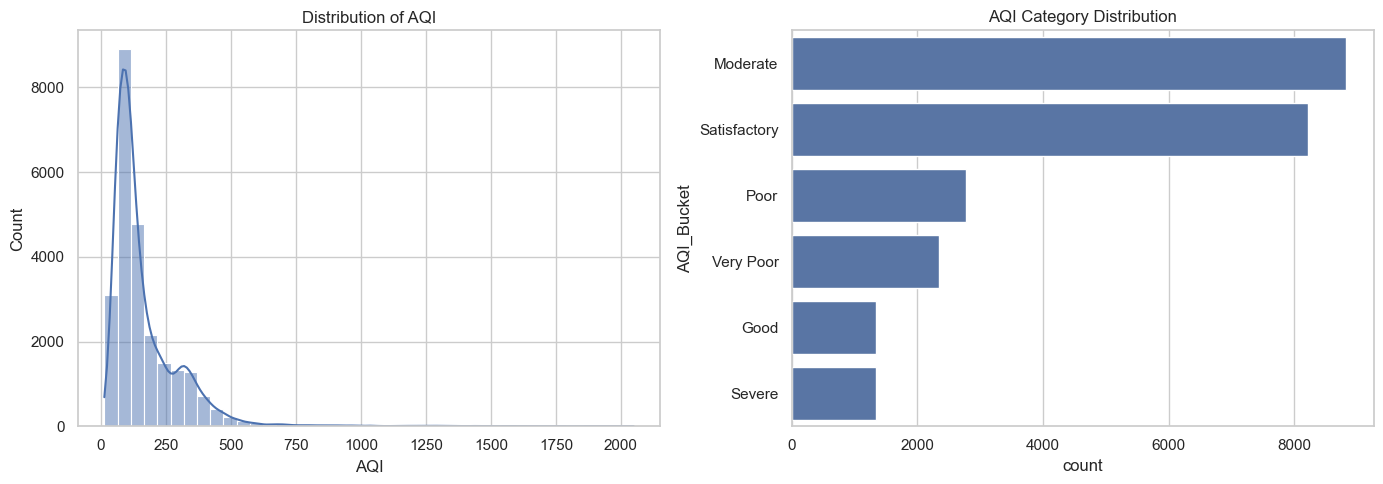

In [6]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(clean_data['AQI'].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title('Distribution of AQI')
sns.countplot(data=clean_data, y='AQI_Bucket', order=clean_data['AQI_Bucket'].value_counts().index, ax=axes[1])
axes[1].set_title('AQI Category Distribution')
plt.tight_layout()


### 2.4 Bivariate Analysis


,City,Mean_AQI,Median_AQI,Records
0,Ahmedabad,452.122939,384.5,1334
10,Delhi,259.487744,257.0,1999
21,Patna,240.782042,215.0,1459
12,Gurugram,225.123882,208.0,1453
19,Lucknow,217.973059,198.0,1893
23,Talcher,172.886819,128.5,698
16,Jorapokhar,159.251621,133.0,771
6,Brajrajnagar,150.280505,122.0,713
18,Kolkata,140.566313,94.0,754
13,Guwahati,140.111111,98.0,495


,City,Mean_AQI,Median_AQI,Records
20,Mumbai,105.352258,91.0,775
17,Kochi,104.284810,99.0,158
7,Chandigarh,96.498328,82.0,299
2,Amaravati,95.299643,78.0,841
4,Bengaluru,94.318325,86.0,1910
11,Ernakulam,92.359477,94.0,153
24,Thiruvananthapuram,75.878327,68.0,1052
9,Coimbatore,73.023256,75.0,344
22,Shillong,53.795122,48.0,205
1,Aizawl,34.765766,23.0,111


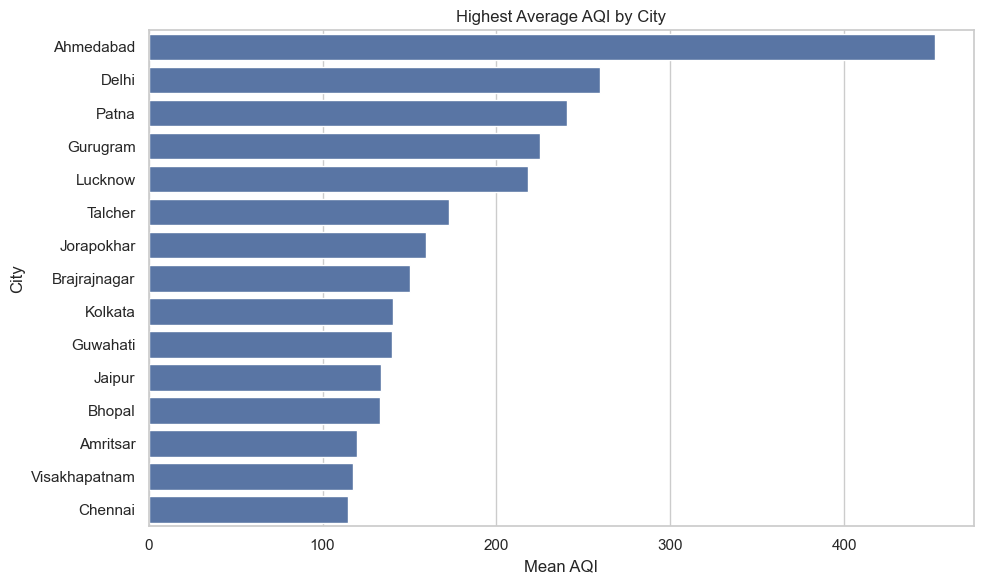

In [7]:
city_summary = city_aqi_summary(clean_data)
display(city_summary.head(10))
display(city_summary.tail(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=city_summary.head(15), x='Mean_AQI', y='City')
plt.title('Highest Average AQI by City')
plt.xlabel('Mean AQI')
plt.ylabel('City')
plt.tight_layout()


,Year,Mean_AQI
0,2015,212.463054
1,2016,197.150019
2,2017,181.472789
3,2018,182.684312
4,2019,156.518173
5,2020,113.520697


,Month,Month_Name,Mean_AQI
0,1,January,231.674918
1,2,February,202.905197
2,3,March,164.735281
3,4,April,143.355120
4,5,May,135.489579
5,6,June,120.198379
6,7,July,111.854575
7,8,August,113.613176
8,9,September,115.191804
9,10,October,188.613552


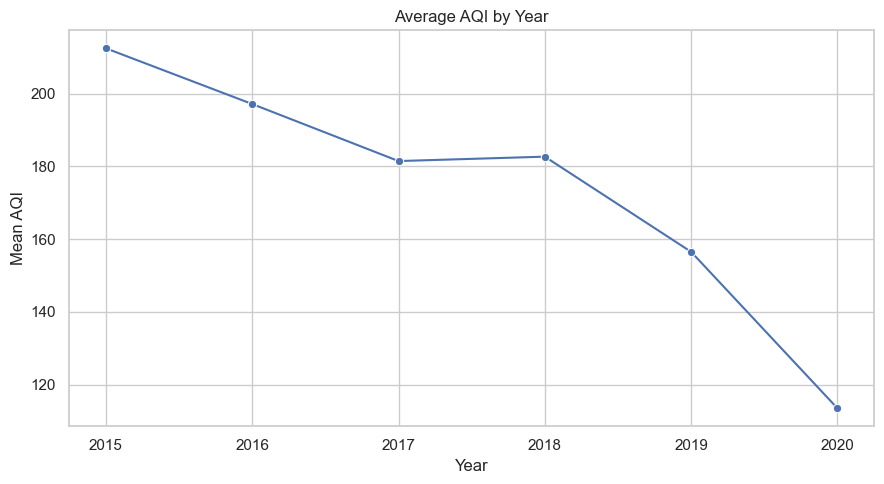

In [8]:
display(yearly_aqi_summary(clean_data))
display(monthly_aqi_summary(clean_data))

plt.figure(figsize=(9, 5))
sns.lineplot(data=yearly_aqi_summary(clean_data), x='Year', y='Mean_AQI', marker='o')
plt.title('Average AQI by Year')
plt.ylabel('Mean AQI')
plt.tight_layout()


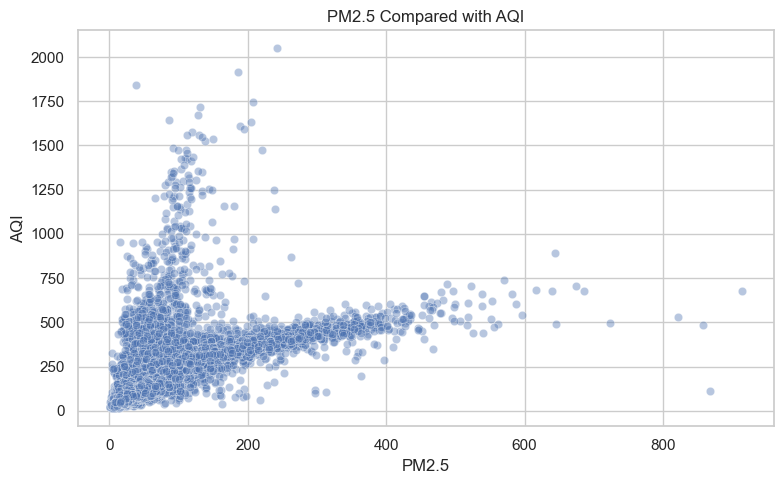

In [9]:
pollutant = 'PM2.5'
plt.figure(figsize=(8, 5))
sns.scatterplot(data=clean_data, x=pollutant, y='AQI', alpha=0.4)
plt.title(f'{pollutant} Compared with AQI')
plt.tight_layout()


### 2.5 Multivariate Analysis


AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64

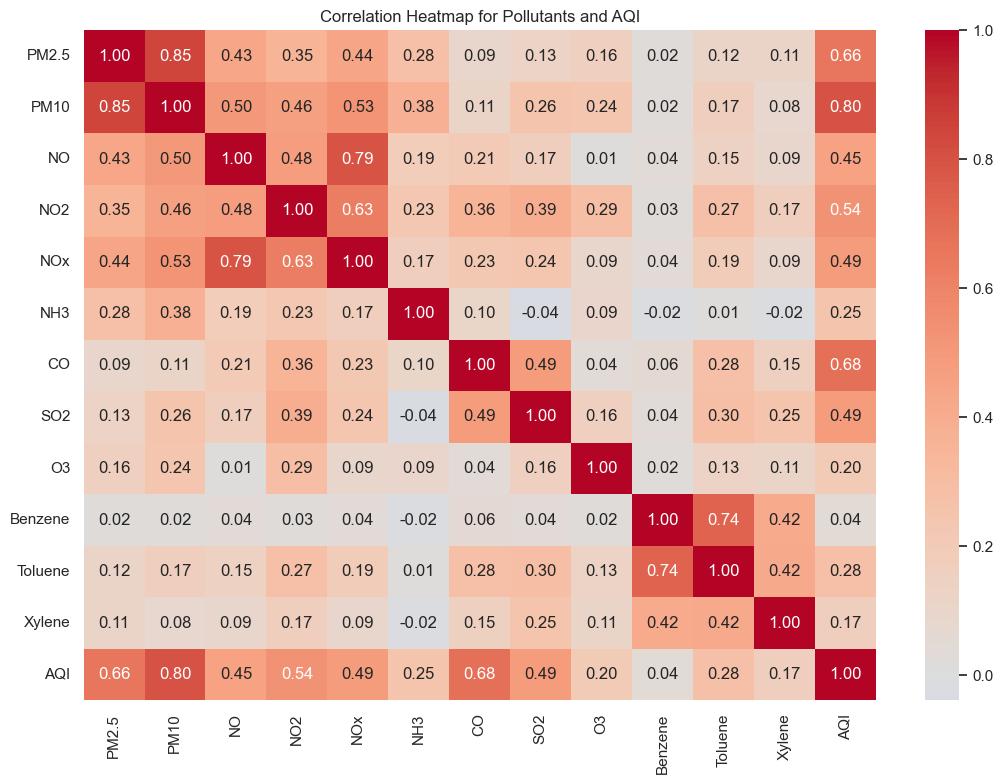

In [10]:
corr = pollutant_correlations(clean_data)
display(corr['AQI'].sort_values(ascending=False))
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap for Pollutants and AQI')
plt.tight_layout()


## Task 3: Model Building

The modelling objective is to predict numerical AQI using pollutant measurements, city, year, and month. `AQI_Bucket` is excluded because it is derived from AQI and would cause target leakage.


In [11]:
best_model, model_results, split_data = train_and_compare_models(clean_data)
display(model_results)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
model_results.to_csv(RESULTS_PATH, index=False)
save_model(best_model, MODEL_PATH)
MODEL_PATH


,Model,R2,MAE,MSE,RMSE
2,Random Forest,0.911537,20.511889,1619.845776,40.247308
3,Gradient Boosting,0.899069,23.122529,1848.146516,42.990075
1,Decision Tree,0.863667,24.535697,2496.392230,49.963909
0,Linear Regression,0.824420,29.977477,3215.053811,56.701445


WindowsPath('D:/Assignments/Gursevak Singh/CMP_7005/models/trained_model.pkl')

## Task 4: Application Development

The project includes a Streamlit application in `app/app.py` with three sections: Data Overview, Exploratory Data Analysis, and Modelling and Prediction. The app uses the reusable modules in `src/` and the saved model in `models/trained_model.pkl`.

Run it with:

```bash
streamlit run app/app.py
```


## Task 5: Version Control

A GitHub repository has been created for this project. Include evidence of regular development commits, the repository structure, and the pushed project files.

Repository URL: `https://github.com/GursevakSingh-ui/CMP_7005_Prac1.git`

Screenshots to add in `assets/screenshots/`:

- GitHub repository file structure
- GitHub commit history
- Streamlit Data Overview page
- Streamlit EDA page
- Streamlit Prediction page


## Task 6: Self Reflection

Complete this section in the student's own words before submission. The reflection should be honest and based on the actual development process. Suggested points to cover are listed below.

### Reflection Draft Placeholder

- Main challenges encountered during the project
- Technical difficulties with Python, data processing, modelling, Streamlit, or GitHub
- Data quality issues such as missing values and separate city files
- EDA decisions and which charts were most useful
- Model-building challenges, including avoiding target leakage from `AQI_Bucket`
- Application development challenges
- Version-control learning and GitHub workflow
- Skills developed during the project
- How the project improved during development
- What would be improved next time

Previous feedback placeholder: add genuine previous assessment feedback here if supplied. If no feedback was supplied, state that no previous assessment feedback was available.


## AI Use Declaration

AI support was used to help structure, code, and review the project. The student must review, understand, test, and adapt the work before submission. All final reflection details and assessment-specific claims should be completed honestly by the student.


## Final Compliance Audit

| Assessment Requirement | Implemented | Evidence or File | Remaining Action |
|---|---|---|---|
| Data imported and inspected | Yes | `src/data_loader.py`, notebook Task 1 | Add written interpretation after running notebook |
| Missing values and duplicates assessed | Yes | `src/eda_functions.py`, notebook Task 2 | Explain chosen handling in final narrative |
| Feature engineering applied | Yes | `src/preprocessing.py` | Justify date features in notebook |
| Univariate EDA | Yes | Notebook Task 2.3, app EDA page | Add interpretation text after outputs |
| Bivariate EDA | Yes | Notebook Task 2.4, app EDA page | Add interpretation text after outputs |
| Multivariate EDA | Yes | Notebook Task 2.5 | Add interpretation text after outputs |
| Model comparison completed | Yes | `models/model_comparison.csv`, notebook Task 3 | Discuss limitations and overfitting risk |
| GUI developed | Yes | `app/app.py`, `app/pages/` | Capture screenshots after testing |
| README and requirements | Yes | `README.md`, `requirements.txt` | Update with GitHub link when available |
| GitHub evidence | Partial | `.gitignore`, README guidance | Create repository, commit history, screenshots |
| Reflection | Partial | Notebook placeholder | Student must complete genuine reflection |
| AI use acknowledged | Drafted | Notebook AI declaration | Adjust to university wording if required |
